In [51]:
from pymatreader import read_mat
connectomes = read_mat('preprocdata/all_data.mat')['all_data']['connectomes'] #variable density for our analysis.


c:\Users\Ale\miniconda3\envs\snakes\Lib\site-packages\pymatreader\utils.py:304: UserWarning: Complex objects (like classes) are not supported. They are imported on a best effort base but your mileage will vary.
  warn(


In [52]:
connectomes.shape

(4216, 90, 90)

In [53]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import scipy.io
import seaborn as sns
import networkx as nx


import pingouin as pg


In [54]:
demo = pd.read_csv('preprocdata/demographics.csv') #density outliers (14) have been excluded but non neurotypical (315) have been included.
demo.columns



# Filter: neurotypical + no outliers
mask = (demo['group'] == 1) & (demo['outlier_index'] == 0) & (demo['dataset'] != 1) & (demo['dataset'] != 2)
demo_clean = demo[mask].reset_index(drop=True)
print(f"Full sample: {len(demo)} | After filtering: {len(demo_clean)}")
print(demo_clean[['age','sex','dataset']].describe())


Full sample: 4216 | After filtering: 3264
               age          sex      dataset
count  3264.000000  3264.000000  3264.000000
mean     36.443934     0.534926     7.216912
std      21.729706     0.498855     1.374255
min       6.000000     0.000000     3.000000
25%      21.000000     0.000000     6.000000
50%      31.000000     1.000000     7.000000
75%      52.000000     1.000000     8.000000
max      90.000000     1.000000     9.000000


In [55]:

# Build clean index (matching MATLAB outlier/group filter)
outlier_idx = np.array(demo['outlier_index']).flatten()
group_idx   = np.array(demo['group']).flatten()
clean_mask  = (group_idx == 1) & (outlier_idx == 0) & (demo['dataset'] != 1) & (demo['dataset'] != 2) 

connectomes = connectomes[clean_mask]   # shape: (N_clean, 90, 90)
ages        = np.array(demo['age']).flatten()[clean_mask]
datasets    = np.array(demo['dataset']).flatten()[clean_mask]
print(f"Connectomes shape: {connectomes.shape}")


Connectomes shape: (3264, 90, 90)


In [47]:
demo=demo_clean

In [62]:

# ── Cell 3: Compute per-subject network metrics ───────────────────
N_subj, N_roi, _ = connectomes.shape
edge_weights_all  = []
degrees           = np.zeros(N_subj)
mean_strengths    = np.zeros(N_subj)
densities_check   = np.zeros(N_subj)

for i in range(N_subj):
    adj = connectomes[i].copy()
    np.fill_diagonal(adj, 0)

    # Upper triangle non-zero weights (undirected, no self-loops)
    upper = adj[np.triu_indices(N_roi, k=1)]
    nz    = upper[upper > 0]
    edge_weights_all.extend(nz.tolist())

    strength          = adj.sum(axis=1)
    degree            = (adj > 0).sum(axis=1)
    degrees[i]        = degree.mean()
    mean_strengths[i] = strength.mean()
    n_edges           = (adj > 0).sum() / 2
    densities_check[i]= n_edges / (N_roi * (N_roi - 1) / 2)

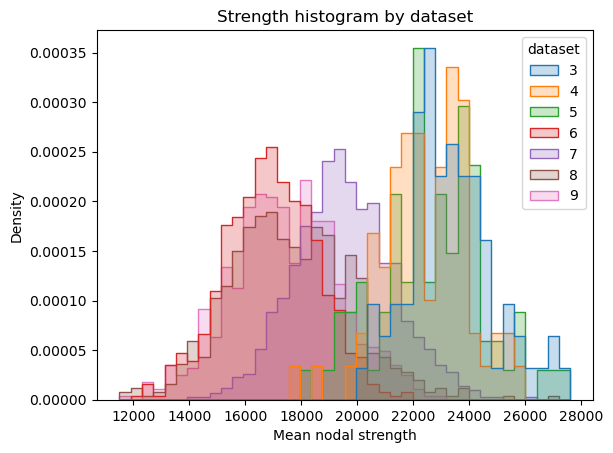

In [63]:
df_strength = pd.DataFrame({
    "dataset": datasets.astype(int).astype(str),
    "mean_strength": mean_strengths
})

sns.histplot(
    data=df_strength,
    x="mean_strength",
    hue="dataset",
    bins=40,
    element="step",
    stat="density",
    common_norm=False
)
plt.xlabel("Mean nodal strength")
plt.title("Strength histogram by dataset")
plt.show()

In [65]:


# ── Cell 4: Plot distributions ────────────────────────────────────
# Ensure numeric array for vectorized math in plots
edge_weights_all = np.asarray(edge_weights_all, dtype=float)
fig.suptitle("Connectome distributions — neurotypical, no outliers\n(variable-density thresholded, normalized weighted)",
             fontsize=13, fontweight='bold')

# 1. Edge weight distribution (log scale)
ax = axes[0,0]
ax.hist(np.log10(edge_weights_all + 1e-10), bins=80, color='steelblue',
        alpha=0.8, edgecolor='white', linewidth=0.3)
ax.set_xlabel("log₁₀(edge weight)"); ax.set_ylabel("Count")
ax.set_title("Edge weight distribution (all non-zero edges)")
ax.axvline(np.log10(np.median(edge_weights_all)), color='red',
           linestyle='--', label=f"Median={np.median(edge_weights_all):.4f}")
ax.legend(fontsize=9)

c:\Users\Ale\miniconda3\envs\snakes\Lib\site-packages\numpy\core\fromnumeric.py:3504: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
c:\Users\Ale\miniconda3\envs\snakes\Lib\site-packages\numpy\core\_methods.py:129: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


C:\Users\Ale\AppData\Local\Temp\ipykernel_16728\4112974407.py:29: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=df_w, x='dataset', y='weight', ax=ax,
C:\Users\Ale\AppData\Local\Temp\ipykernel_16728\4112974407.py:62: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_dens, x='dataset', y='density', ax=ax,


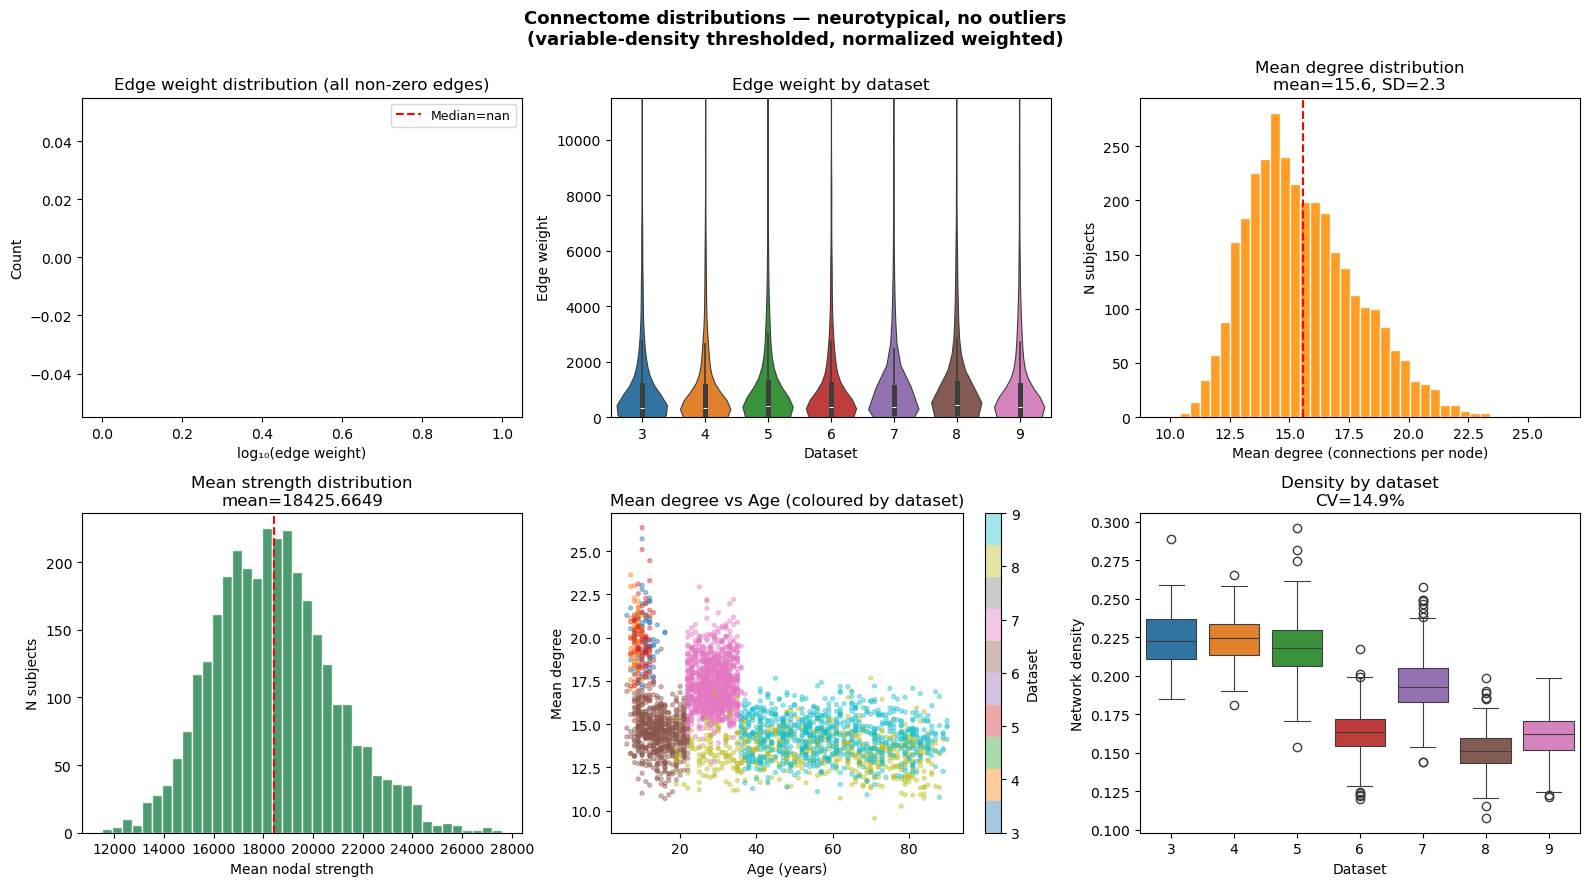

Saved: results/connectome_distributions.png


In [66]:


# ── Cell 4: Plot distributions ────────────────────────────────────
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
fig.suptitle("Connectome distributions — neurotypical, no outliers\n(variable-density thresholded, normalized weighted)",
             fontsize=13, fontweight='bold')

# 1. Edge weight distribution (log scale)
ax = axes[0,0]
ax.hist(np.log10(edge_weights_all + 1e-10), bins=80, color='steelblue',
        alpha=0.8, edgecolor='white', linewidth=0.3)
ax.set_xlabel("log₁₀(edge weight)"); ax.set_ylabel("Count")
ax.set_title("Edge weight distribution (all non-zero edges)")
ax.axvline(np.log10(np.median(edge_weights_all)), color='red',
           linestyle='--', label=f"Median={np.median(edge_weights_all):.4f}")
ax.legend(fontsize=9)

# 2. Edge weight by dataset (violin)
ax = axes[0,1]
# Sample max 5000 weights per dataset for speed
sample_df = []
for ds in np.unique(datasets):
    idx = np.where(datasets == ds)[0][:50]  # 50 subjects per dataset
    w   = []
    for i in idx:
        adj = connectomes[i].copy(); np.fill_diagonal(adj,0)
        upper = adj[np.triu_indices(N_roi,k=1)]; w.extend(upper[upper>0].tolist())
    sample_df.extend([{'dataset':str(int(ds)),'weight':v} for v in
                       np.random.choice(w, min(len(w),2000), replace=False)])
df_w = pd.DataFrame(sample_df)
sns.violinplot(data=df_w, x='dataset', y='weight', ax=ax,
               palette='tab10', inner='box', linewidth=0.8)
ax.set_xlabel("Dataset"); ax.set_ylabel("Edge weight")
ax.set_title("Edge weight by dataset")
ax.set_ylim(0, np.percentile(df_w['weight'], 99))

# 3. Degree distribution
ax = axes[0,2]
ax.hist(degrees, bins=40, color='darkorange', alpha=0.85, edgecolor='white')
ax.set_xlabel("Mean degree (connections per node)")
ax.set_ylabel("N subjects")
ax.set_title(f"Mean degree distribution\nmean={degrees.mean():.1f}, SD={degrees.std():.1f}")
ax.axvline(degrees.mean(), color='red', linestyle='--')

# 4. Mean strength distribution
ax = axes[1,0]
ax.hist(mean_strengths, bins=40, color='seagreen', alpha=0.85, edgecolor='white')
ax.set_xlabel("Mean nodal strength"); ax.set_ylabel("N subjects")
ax.set_title(f"Mean strength distribution\nmean={mean_strengths.mean():.4f}")
ax.axvline(mean_strengths.mean(), color='red', linestyle='--')

# 5. Degree vs Age (scatter)
ax = axes[1,1]
sc = ax.scatter(ages, degrees, c=datasets, cmap='tab10',
                alpha=0.4, s=8)
ax.set_xlabel("Age (years)"); ax.set_ylabel("Mean degree")
ax.set_title("Mean degree vs Age (coloured by dataset)")
plt.colorbar(sc, ax=ax, label='Dataset')

# 6. Density by dataset (box)
ax = axes[1,2]
df_dens = pd.DataFrame({'dataset': datasets.astype(int).astype(str),
                         'density': densities_check})
sns.boxplot(data=df_dens, x='dataset', y='density', ax=ax,
            palette='tab10', linewidth=0.8)
ax.set_xlabel("Dataset"); ax.set_ylabel("Network density")
ax.set_title(f"Density by dataset\nCV={100*densities_check.std()/densities_check.mean():.1f}%")

plt.tight_layout()
plt.savefig('results/connectome_distributions.png', dpi=200, bbox_inches='tight')
plt.savefig('results/connectome_distributions.svg', bbox_inches='tight')
plt.show()
print("Saved: results/connectome_distributions.png")

In [68]:
demo=demo_clean

In [69]:
# ================================================================
# PART 1: Justify not using Alexa's thresholding
# Show edge weight distribution vs where thresholds fall.
# If no natural gap at the threshold → cut is arbitrary.
# ================================================================

# ── Cell 1: Load raw (unthresholded) connectomes + thresholds ────
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import pandas as pd
import scipy.io
import seaborn as sns

mat = scipy.io.loadmat('preprocdata/thresholded_data.mat', simplify_cells=True)

# Raw streamline counts: variable_weighted has had threshold applied.
# We need all_data.mat (pre-threshold) for unthresholded weights.
# If you only have thresholded_data, use variable_weighted as proxy
# (non-zero values = streamlines that survived the threshold).
# Load all_data for true unthresholded view:
try:
    raw_conn=connectomes
    demo_raw = demo
    outlier  = np.array(demo_raw['outlier_index']).flatten()
    group    = np.array(demo_raw['group']).flatten()
    ages_raw = np.array(demo_raw['age']).flatten()
    clean    = (group == 1) & (outlier == 0)
    raw_conn = raw_conn[clean]
    ages_raw = ages_raw[clean]
    print(f"Unthresholded connectomes: {raw_conn.shape}, dtype={raw_conn.dtype}")
    have_raw = True
except Exception as e:
    print(f"all_data.mat not found ({e}). Using variable_weighted as proxy.")
    raw_conn = mat['thresholded_data']['connectomes']['variable_weighted']
    demo_t   = mat['thresholded_data']['demographics']
    ages_raw = np.array(demo_t['age']).flatten()
    have_raw = False

# Thresholds Alexa applied (one per age×dataset bin)
var_thresholds = np.array(
    mat['thresholded_data']['thresholds']['variable']).flatten()
print(f"Variable-density thresholds: {len(var_thresholds)} bins, "
      f"range {var_thresholds.min():.0f}–{var_thresholds.max():.0f}")

Unthresholded connectomes: (3264, 90, 90), dtype=int32
Variable-density thresholds: 190 bins, range 73–426


In [70]:

# ── Cell 2: Distribution of ALL edge weights ──────────────────────
# Flat list of every non-zero upper-triangle weight across all subjects
N_subj, N_roi, _ = raw_conn.shape
all_weights = []
age_of_weight = []  # track age for each weight

np.random.seed(42)
sample_idx = np.random.choice(N_subj, min(N_subj, 500), replace=False)

for i in sample_idx:
    adj = raw_conn[i].copy().astype(float)
    np.fill_diagonal(adj, 0)
    upper = adj[np.triu_indices(N_roi, k=1)]
    nz    = upper[upper > 0]
    all_weights.extend(nz.tolist())
    age_of_weight.extend([ages_raw[i]] * len(nz))

all_weights    = np.array(all_weights)
age_of_weight  = np.array(age_of_weight)

print(f"Non-zero edges sampled: {len(all_weights):,}")
print(f"Weight range: {all_weights.min():.4f} – {all_weights.max():.4f}")

Non-zero edges sampled: 356,236
Weight range: 16.0000 – 102435.0000


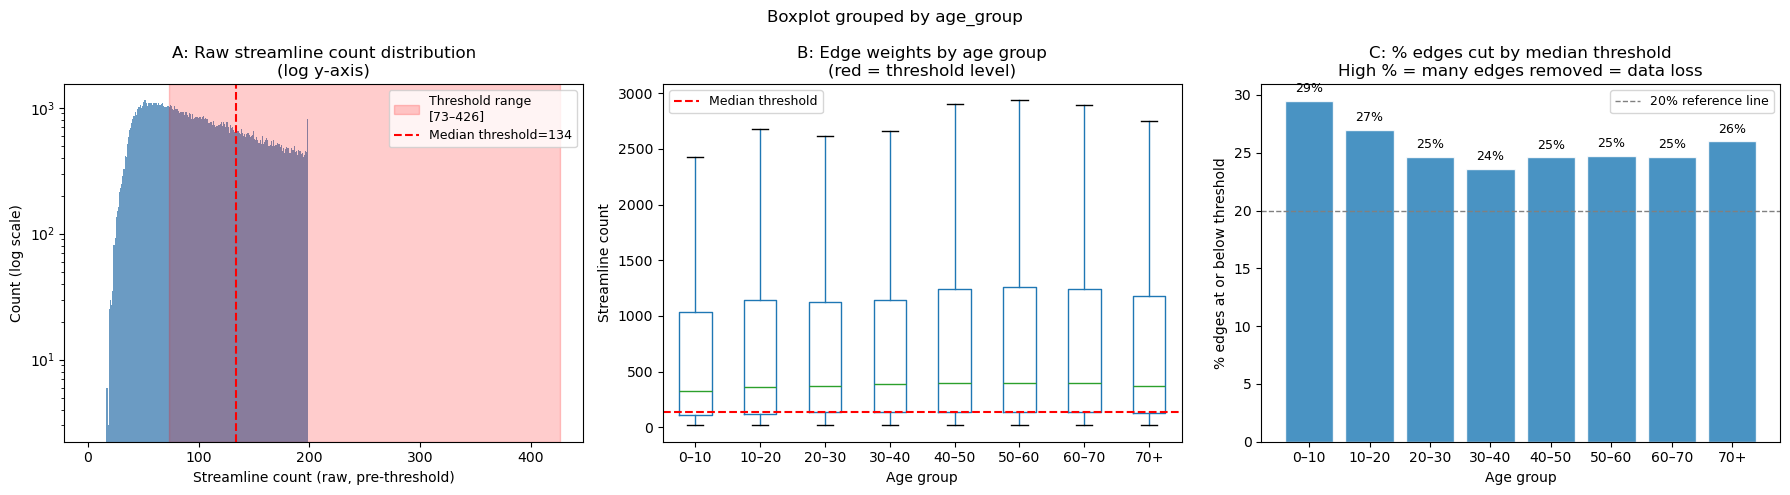

Saved: results/thresholding/threshold_justification.png


In [71]:
import os
# ── Cell 3: THE KEY PLOT — distribution + threshold lines ─────────
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle(
    "Edge weight distribution vs. Alexa's threshold cutpoints\n"
    "If no gap at threshold → cut is continuous → thresholding is arbitrary",
    fontsize=13, fontweight='bold')



# Panel A: Log-scale histogram of all edge weights
ax = axes[0]
if have_raw:
    # Integer streamline counts: show linear histogram with threshold lines
    bins = np.arange(0, min(all_weights.max()+2, 200), 1)
    ax.hist(all_weights, bins=bins, color='steelblue', alpha=0.8,
            edgecolor='none', log=True)
    ax.set_xlabel("Streamline count (raw, pre-threshold)")
    ax.set_title("A: Raw streamline count distribution\n(log y-axis)")
    # Overlay threshold range
    t_lo, t_hi = var_thresholds.min(), var_thresholds.max()
    ax.axvspan(t_lo, t_hi, alpha=0.2, color='red',
               label=f"Threshold range\n[{t_lo:.0f}–{t_hi:.0f}]")
    ax.axvline(np.median(var_thresholds), color='red', linestyle='--', lw=1.5,
               label=f"Median threshold={np.median(var_thresholds):.0f}")
    ax.legend(fontsize=9)
else:
    # Normalized weights after threshold — show where distribution starts
    ax.hist(np.log10(all_weights + 1e-10), bins=80, color='steelblue', alpha=0.8)
    ax.set_xlabel("log₁₀(normalized edge weight)")
    ax.set_title("A: Edge weight distribution (post-threshold proxy)")
ax.set_ylabel("Count (log scale)")

# Panel B: Weights by age group (shows whether threshold tracks biology)
ax = axes[1]
age_bins  = [0,10,20,30,40,50,60,70,100]
age_labels = ['0–10','10–20','20–30','30–40','40–50','50–60','60–70','70+']
age_groups = pd.cut(age_of_weight, bins=age_bins, labels=age_labels, right=False)
df_age = pd.DataFrame({'weight': all_weights, 'age_group': age_groups})
if have_raw:
    # Box plot of streamline counts per age group
    df_age.boxplot(column='weight', by='age_group', ax=ax,
                   showfliers=False, grid=False)
    ax.set_ylabel("Streamline count")
    # Age-specific threshold (median per bin where we know it)
    ax.axhline(np.median(var_thresholds), color='red', linestyle='--', lw=1.5,
               label=f"Median threshold")
    ax.legend(fontsize=9)
else:
    df_age.boxplot(column='weight', by='age_group', ax=ax,
                   showfliers=False, grid=False)
    ax.set_ylabel("Normalized edge weight")
ax.set_xlabel("Age group")
ax.set_title("B: Edge weights by age group\nRed = threshold level")
plt.sca(ax); plt.title("B: Edge weights by age group\n(red = threshold level)")

# Panel C: Proportion of edges BELOW threshold across age groups
ax = axes[2]
pct_cut = []
for lo, hi, lbl in zip(age_bins[:-1], age_bins[1:], age_labels):
    mask  = (age_of_weight >= lo) & (age_of_weight < hi)
    w     = all_weights[mask]
    if len(w) == 0:
        pct_cut.append(np.nan); continue
    # Use median threshold as the cutpoint proxy
    thr = np.median(var_thresholds) if have_raw else 0
    pct_cut.append(100 * np.mean(w <= thr))

bars = ax.bar(age_labels, pct_cut,
              color=['#E74C3C' if p > 30 else '#2980B9' for p in pct_cut],
              alpha=0.85, edgecolor='white')
ax.set_xlabel("Age group")
ax.set_ylabel("% edges at or below threshold")
ax.set_title("C: % edges cut by median threshold\nHigh % = many edges removed = data loss")
ax.axhline(20, color='grey', linestyle='--', lw=1,
           label="20% reference line")
for bar, pct in zip(bars, pct_cut):
    if not np.isnan(pct):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
                f"{pct:.0f}%", ha='center', va='bottom', fontsize=9)
ax.legend(fontsize=9)

plt.tight_layout()
os.makedirs('results/thresholding', exist_ok=True)
plt.savefig('results/thresholding/threshold_justification.png', dpi=200,
            bbox_inches='tight')
plt.savefig('results/thresholding/threshold_justification.svg',
            bbox_inches='tight')
plt.show()
print("Saved: results/thresholding/threshold_justification.png")



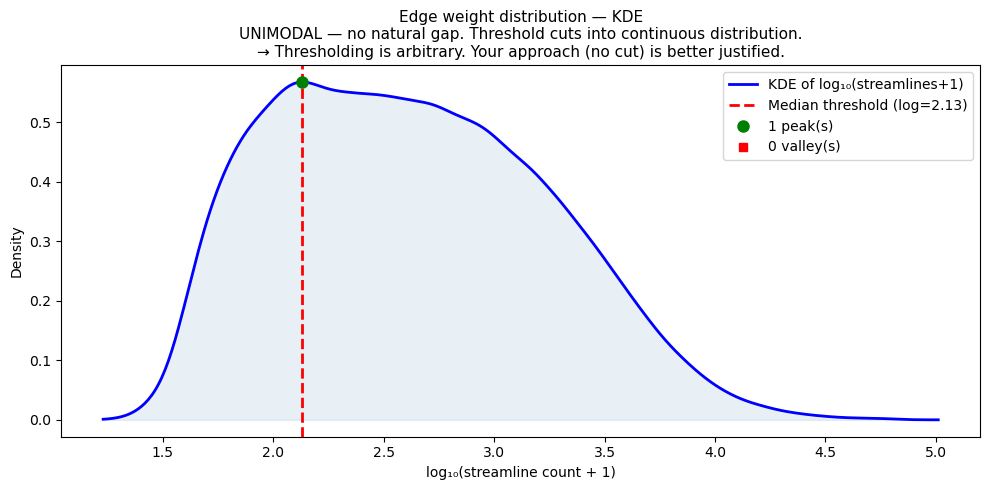


VERDICT: UNIMODAL — no natural gap. Threshold cuts into continuous distribution.
→ Thresholding is arbitrary. Your approach (no cut) is better justified.


In [72]:



# ── Cell 4: Continuity test — is the distribution unimodal? ───────
# A bimodal distribution with a natural valley at the threshold
# would JUSTIFY the cut. A unimodal distribution would NOT.
from scipy.signal import find_peaks
from scipy.stats import gaussian_kde

fig, ax = plt.subplots(figsize=(10, 5))
w_sample = all_weights[all_weights > 0]
if have_raw:
    # KDE on log scale for integer counts
    w_log = np.log10(w_sample + 1)
    kde   = gaussian_kde(w_log, bw_method=0.1)
    x_log = np.linspace(w_log.min(), w_log.max(), 500)
    y_kde = kde(x_log)
    ax.plot(x_log, y_kde, 'b-', lw=2, label="KDE of log₁₀(streamlines+1)")
    ax.set_xlabel("log₁₀(streamline count + 1)")
    thr_log = np.log10(np.median(var_thresholds) + 1)
    ax.axvline(thr_log, color='red', linestyle='--', lw=2,
               label=f"Median threshold (log={thr_log:.2f})")
else:
    w_log = np.log10(w_sample + 1e-10)
    kde   = gaussian_kde(w_log, bw_method=0.15)
    x_log = np.linspace(w_log.min(), w_log.max(), 500)
    y_kde = kde(x_log)
    ax.plot(x_log, y_kde, 'b-', lw=2, label="KDE of log₁₀(weight)")
    ax.set_xlabel("log₁₀(weight)")

# Find peaks and valleys
peaks, _   = find_peaks(y_kde,   height=0.05*y_kde.max(), distance=20)
valleys, _ = find_peaks(-y_kde,  distance=20)
ax.plot(x_log[peaks],   y_kde[peaks],   'go', ms=8, label=f"{len(peaks)} peak(s)")
ax.plot(x_log[valleys], y_kde[valleys], 'rs', ms=6, label=f"{len(valleys)} valley(s)")

n_peaks = len(peaks)
if n_peaks == 1:
    verdict = "UNIMODAL — no natural gap. Threshold cuts into continuous distribution.\n→ Thresholding is arbitrary. Your approach (no cut) is better justified."
elif n_peaks >= 2:
    verdict = f"MULTIMODAL ({n_peaks} peaks) — potential natural gap exists.\n→ Check whether threshold falls at a valley. If yes, Alexa's cut may be defensible."
else:
    verdict = "Flat/unclear distribution."

ax.set_title(f"Edge weight distribution — KDE\n{verdict}", fontsize=11)
ax.set_ylabel("Density")
ax.legend(fontsize=10)
ax.fill_between(x_log, 0, y_kde, alpha=0.12, color='steelblue')
plt.tight_layout()
plt.savefig('results/thresholding/unimodal_test.png', dpi=200, bbox_inches='tight')
plt.show()
print(f"\nVERDICT: {verdict}")



In [73]:


# ================================================================
# PART 2: Community detection — age-related modularity
# Literature: modularity Q peaks in young adults and declines with age
# (Betzel et al. 2014, Chan et al. 2014, Meunier et al. 2009)
# ================================================================

# ── Cell 5: Compute modularity Q per subject ─────────────────────
import networkx as nx
from scipy.linalg import eigh
def modularity_louvain_nx(adj):
    """
    Modularity Q via networkx greedy_modularity_communities.
    Returns Q and number of communities.
    """
    G = nx.from_numpy_array(adj)
    G.remove_nodes_from(list(nx.isolates(G)))
    if G.number_of_edges() == 0:
        return np.nan, np.nan
    communities = nx.community.greedy_modularity_communities(G, weight="weight")
    Q = nx.community.modularity(G, communities, weight="weight")
    return Q, len(communities)

def _modularity_one_subject(adj):
    adj = adj.copy()
    np.fill_diagonal(adj, 0)
    return modularity_louvain_nx(adj)

def modularity_louvain_parallel(connectomes, n_jobs=-1):
    """
    Parallel modularity computation across subjects.
    n_jobs=-1 uses all available CPU cores.
    """
    results = Parallel(n_jobs=n_jobs, prefer="processes")(
        delayed(_modularity_one_subject)(connectomes[i]) for i in range(len(connectomes))
    )
    Q_vals = np.array([r[0] for r in results], dtype=float)
    ncomm = np.array([r[1] for r in results], dtype=float)
    return Q_vals, ncomm

In [75]:

Q_vals, ncomm = modularity_louvain_parallel(connectomes, n_jobs=-1)

Computing modularity for 3889 subjects...
  0/3889
  200/3889
  400/3889
  600/3889
  800/3889
  1000/3889
  1200/3889
  1400/3889
  1600/3889
  1800/3889
  2000/3889
  2200/3889
  2400/3889
  2600/3889
  2800/3889
  3000/3889
  3200/3889
  3400/3889
  3600/3889
  3800/3889

Modularity Q: mean=0.509, SD=0.031, range [0.414, 0.640]
Saved: procdata/community_metrics.csv


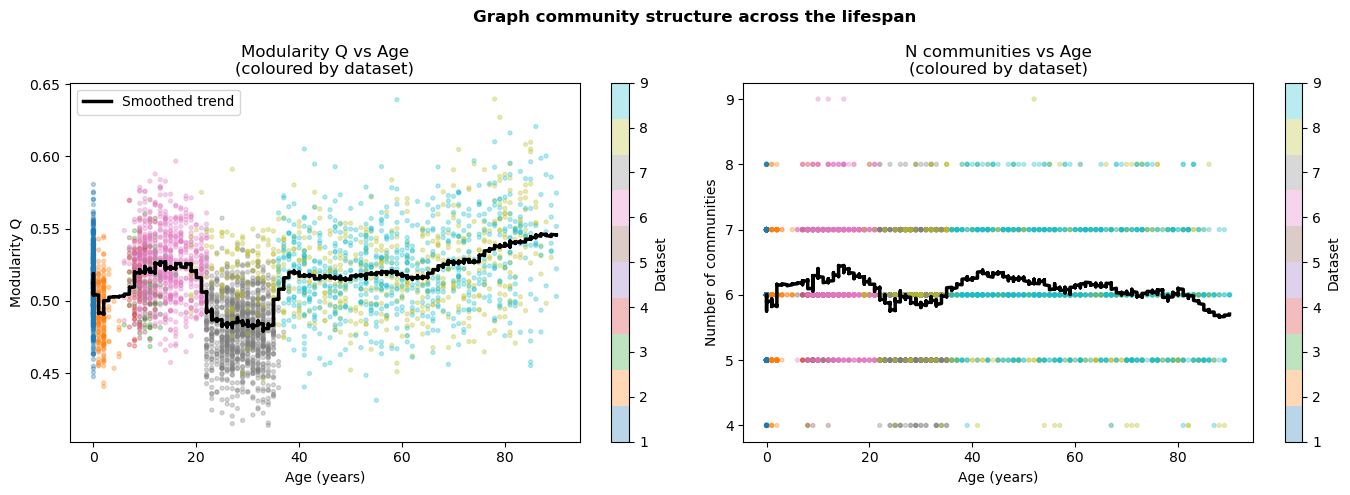

Saved: results/communities/modularity_vs_age.png


In [ ]:
for i in range(len(conn_vd)):
    adj = conn_vd[i].copy()
    np.fill_diagonal(adj, 0)
    Q_vals[i], ncomm[i] = modularity_louvain_nx(adj)
    if i % 200 == 0: print(f"  {i}/{len(conn_vd)}")

print(f"\nModularity Q: mean={np.nanmean(Q_vals):.3f}, "
      f"SD={np.nanstd(Q_vals):.3f}, "
      f"range [{np.nanmin(Q_vals):.3f}, {np.nanmax(Q_vals):.3f}]")

# Save for R
df_comm = pd.DataFrame({
    'age': ages_t, 'dataset': datasets_t,
    'modularity_Q': Q_vals, 'n_communities': ncomm
})
# Merge with existing demographics CSV if available
try:
    demo_csv = pd.read_csv('preprocdata/demographics_with_graph_metrics.csv')
    # Assumes row order is preserved after group filter
    df_comm.index = demo_csv.index[:len(df_comm)]
    df_out = pd.concat([demo_csv.iloc[:len(df_comm)].reset_index(drop=True),
                        df_comm[['modularity_Q','n_communities']].reset_index(drop=True)],
                       axis=1)
    df_out.to_csv('procdata/demographics_with_community_metrics.csv', index=False)
    print("Saved: procdata/demographics_with_community_metrics.csv")
except FileNotFoundError:
    df_comm.to_csv('procdata/community_metrics.csv', index=False)
    print("Saved: procdata/community_metrics.csv")

# ── Cell 6: Modularity vs Age plot ───────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Graph community structure across the lifespan", fontweight='bold')

ax = axes[0]
sc = ax.scatter(ages_t, Q_vals, c=datasets_t, cmap='tab10',
                alpha=0.3, s=8)
# Smooth trend (lowess)
from scipy.ndimage import uniform_filter1d
from joblib import Parallel, delayed
sort_idx = np.argsort(ages_t)
age_s    = ages_t[sort_idx]
q_s      = Q_vals[sort_idx]
q_smooth = uniform_filter1d(q_s, size=max(len(q_s)//30, 10))
ax.plot(age_s, q_smooth, 'k-', lw=2.5, label="Smoothed trend")
ax.set_xlabel("Age (years)"); ax.set_ylabel("Modularity Q")
ax.set_title("Modularity Q vs Age\n(coloured by dataset)")
ax.legend()
plt.colorbar(sc, ax=ax, label='Dataset')

ax = axes[1]
sc2 = ax.scatter(ages_t, ncomm, c=datasets_t, cmap='tab10',
                 alpha=0.3, s=8)
nc_s      = ncomm[sort_idx]
nc_smooth = uniform_filter1d(nc_s, size=max(len(nc_s)//30, 10))
ax.plot(age_s, nc_smooth, 'k-', lw=2.5)
ax.set_xlabel("Age (years)"); ax.set_ylabel("Number of communities")
ax.set_title("N communities vs Age\n(coloured by dataset)")
plt.colorbar(sc2, ax=ax, label='Dataset')

plt.tight_layout()
os.makedirs('results/communities', exist_ok=True)
plt.savefig('results/communities/modularity_vs_age.png', dpi=200, bbox_inches='tight')
plt.show()
print("Saved: results/communities/modularity_vs_age.png")

In [20]:

def calc_node_disparity(adj):
    """Calcula grado k_i y disparidad Y_i."""
    k = np.count_nonzero(adj, axis=1)
    s = np.sum(adj, axis=1)
    s_safe = np.where(s == 0, 1, s)
    
    p = adj / s_safe[:, None]
    Y = np.sum(p**2, axis=1)
    return k, Y

def get_global_disparity_ratio_null(adj):
    k, Y = calc_node_disparity(adj)
    mask = k > 1
    
    if np.sum(mask) == 0:
        return np.nan
        
    Y_null = 2.0 / (k[mask] + 1.0)
    deviation = Y[mask] / Y_null
    
    return np.mean(deviation)

deviations = [get_global_disparity_ratio_null(adj) for adj in connectomes]

# 3. Añadir al dataframe y guardar
demo['Disparity_Ratio'] = deviations

#Calculate density by comparing to a fully connected graph of 90 nodes (without self-loops)
density = np.array([np.sum(connectomes[i] > 0) / (90 * 89) for i in range(len(connectomes))])
demo['Density'] = density

# Eliminar posibles NaNs si algún sujeto falló o tenía k<=1 en todos los nodos
demo = demo.dropna(subset=['Disparity_Ratio', 'Density'])

demo.to_csv('procdata/demographics_with_disparity_dev_unthresholded.csv', index=False)





<Axes: xlabel='age', ylabel='Disparity_Deviation'>

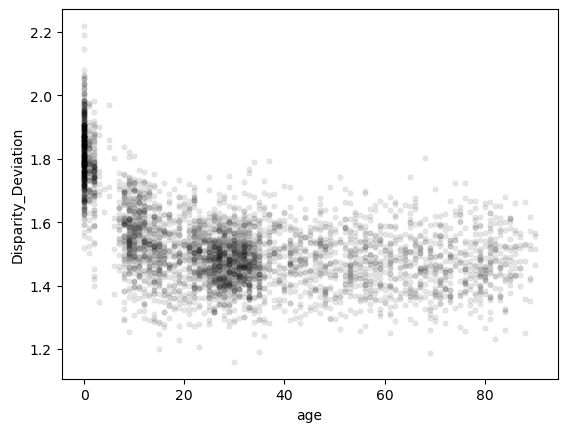

In [ ]:
# Nube de puntos
import seaborn as sns
sns.scatterplot(
    data=demo,
    x='age',
    y='Disparity_Deviation',
    alpha=0.1, color='black', s=15, edgecolor=None
)

In [ ]:
demo.to_csv('procdata/demographics_with_disparity_dev.csv', index=False)